# GovReport Training Dataset Analysis

Complete analysis of ALL scored GovReport samples, including quality distribution.

**Data Source:**
- Documents & Summaries: GovReport dataset (HuggingFace)
- Scores: `../data/scores_progress.jsonl` (all samples judged by Nemotron Nano 9B)

**Analysis includes:**
- Full dataset statistics (all scored samples)
- Context length distribution (8K/16K/32K)
- Score distribution (coverage & specificity)
- Low/borderline quality examples
- High-quality subset that passed filter (coverage ≥4, specificity ≥4)

In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from datasets import load_dataset
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data

In [2]:
# Load GovReport dataset (original source)
print("Loading GovReport dataset...")
govreport = load_dataset("ccdv/govreport-summarization")
train_data = govreport["train"]
print(f"  Total GovReport train samples: {len(train_data):,}")

# Load ALL scores
scores_file = Path('../data/scores_progress.jsonl')
print(f"\nLoading scores from: {scores_file}")

all_scores = []
with open(scores_file) as f:
    for line in f:
        if line.strip():
            all_scores.append(json.loads(line))

print(f"  Total scored samples: {len(all_scores):,}")

# Separate successful vs failed
successful_scores = [s for s in all_scores if s.get('success', False)]
failed_scores = [s for s in all_scores if not s.get('success', False)]

print(f"  Successful scoring: {len(successful_scores):,} ({len(successful_scores)/len(all_scores)*100:.1f}%)")
print(f"  Failed scoring: {len(failed_scores):,} ({len(failed_scores)/len(all_scores)*100:.1f}%)")

Loading GovReport dataset...
  Total GovReport train samples: 17,517

Loading scores from: ../data/scores_progress.jsonl
  Total scored samples: 18,490
  Successful scoring: 18,452 (99.8%)
  Failed scoring: 38 (0.2%)


## 2. Extract Documents & Summaries for ALL Scored Samples

In [3]:
# Extract documents and summaries for ALL successfully scored samples
print("\nExtracting all scored samples...")

all_data = []
for score in successful_scores:
    sample_id = score['sample_id']
    if sample_id < len(train_data):
        sample = train_data[sample_id]
        all_data.append({
            'sample_id': sample_id,
            'document': sample['report'],
            'summary': sample['summary'],
            'coverage': score['coverage'],
            'specificity': score['specificity']
        })

print(f"  Extracted {len(all_data):,} samples with valid scores")

# Separate for analysis
docs = [d['document'] for d in all_data]
summaries = [d['summary'] for d in all_data]


Extracting all scored samples...
  Extracted 17,481 samples with valid scores


## 3. Character Length Analysis (All Data)

In [4]:
# Calculate character lengths for ALL data
doc_chars = [len(d) for d in docs]
summary_chars = [len(s) for s in summaries]

print("\n" + "="*80)
print("CHARACTER LENGTH STATISTICS (All Scored Samples)")
print("="*80)

print("\nDocuments:")
print(f"  Min:    {min(doc_chars):,} chars")
print(f"  Max:    {max(doc_chars):,} chars")
print(f"  Mean:   {np.mean(doc_chars):,.0f} chars")
print(f"  Median: {np.median(doc_chars):,.0f} chars")
print(f"  Std:    {np.std(doc_chars):,.0f} chars")

print("\nSummaries:")
print(f"  Min:    {min(summary_chars):,} chars")
print(f"  Max:    {max(summary_chars):,} chars")
print(f"  Mean:   {np.mean(summary_chars):,.0f} chars")
print(f"  Median: {np.median(summary_chars):,.0f} chars")
print(f"  Std:    {np.std(summary_chars):,.0f} chars")

compression_ratios = [d/s if s > 0 else 0 for d, s in zip(doc_chars, summary_chars)]
print("\nCompression Ratio:")
print(f"  Mean:   {np.mean(compression_ratios):.1f}x")
print(f"  Median: {np.median(compression_ratios):.1f}x")


CHARACTER LENGTH STATISTICS (All Scored Samples)

Documents:
  Min:    320 chars
  Max:    600,181 chars
  Mean:   50,880 chars
  Median: 42,523 chars
  Std:    37,166 chars

Summaries:
  Min:    127 chars
  Max:    13,652 chars
  Mean:   3,202 chars
  Median: 3,263 chars
  Std:    1,150 chars

Compression Ratio:
  Mean:   17.9x
  Median: 13.9x


## 4. Token Length Distribution (8K/16K/32K) - All Data

In [5]:
# Load Qwen2.5 tokenizer for accurate token counting
from transformers import AutoTokenizer

print("\nLoading Qwen2.5 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
print("✓ Tokenizer loaded")

# Tokenize all documents and summaries (this may take a few minutes)
print("\nTokenizing all samples (this may take 2-3 minutes)...")
print("  Processing documents...")
doc_tokens = []
for i, doc in enumerate(docs):
    if i % 1000 == 0:
        print(f"    {i}/{len(docs)} documents tokenized...")
    tokens = tokenizer(doc, truncation=False, add_special_tokens=False)['input_ids']
    doc_tokens.append(len(tokens))

print("  Processing summaries...")
summary_tokens = []
for i, summary in enumerate(summaries):
    if i % 1000 == 0:
        print(f"    {i}/{len(summaries)} summaries tokenized...")
    tokens = tokenizer(summary, truncation=False, add_special_tokens=False)['input_ids']
    summary_tokens.append(len(tokens))

total_tokens = [d + s for d, s in zip(doc_tokens, summary_tokens)]
print("✓ Tokenization complete")

# Categorize by context length
def categorize_length(tokens):
    if tokens <= 8192:
        return '8K'
    elif tokens <= 16384:
        return '16K'
    elif tokens <= 32768:
        return '32K'
    else:
        return '>32K'

categories = [categorize_length(t) for t in total_tokens]
category_counts = Counter(categories)

print("\n" + "="*80)
print("CONTEXT LENGTH DISTRIBUTION (All Scored Samples - REAL TOKENS)")
print("="*80)
print(f"\n8K (≤8,192 tokens):    {category_counts.get('8K', 0):5d} samples ({category_counts.get('8K', 0)/len(docs)*100:.1f}%)")
print(f"16K (8K-16K tokens):   {category_counts.get('16K', 0):5d} samples ({category_counts.get('16K', 0)/len(docs)*100:.1f}%)")
print(f"32K (16K-32K tokens):  {category_counts.get('32K', 0):5d} samples ({category_counts.get('32K', 0)/len(docs)*100:.1f}%)")
print(f">32K (>32K tokens):    {category_counts.get('>32K', 0):5d} samples ({category_counts.get('>32K', 0)/len(docs)*100:.1f}%)")
print(f"\nTotal: {len(docs):,} samples")

print(f"\nToken Statistics:")
print(f"  Document tokens:")
print(f"    Min:    {min(doc_tokens):,}")
print(f"    Max:    {max(doc_tokens):,}")
print(f"    Mean:   {np.mean(doc_tokens):,.0f}")
print(f"    Median: {np.median(doc_tokens):,.0f}")
print(f"  Summary tokens:")
print(f"    Min:    {min(summary_tokens):,}")
print(f"    Max:    {max(summary_tokens):,}")
print(f"    Mean:   {np.mean(summary_tokens):,.0f}")
print(f"    Median: {np.median(summary_tokens):,.0f}")
print(f"  Total tokens (doc+summary):")
print(f"    Min:    {min(total_tokens):,}")
print(f"    Max:    {max(total_tokens):,}")
print(f"    Mean:   {np.mean(total_tokens):,.0f}")
print(f"    Median: {np.median(total_tokens):,.0f}")

# Cumulative coverage
print("\nCumulative Coverage:")
print(f"  ≤8K:  {category_counts.get('8K', 0)/len(docs)*100:.1f}%")
print(f"  ≤16K: {(category_counts.get('8K', 0) + category_counts.get('16K', 0))/len(docs)*100:.1f}%")
print(f"  ≤32K: {(category_counts.get('8K', 0) + category_counts.get('16K', 0) + category_counts.get('32K', 0))/len(docs)*100:.1f}%")


Loading Qwen2.5 tokenizer...
✓ Tokenizer loaded

Tokenizing all samples (this may take 2-3 minutes)...
  Processing documents...
    0/17481 documents tokenized...
    1000/17481 documents tokenized...
    2000/17481 documents tokenized...
    3000/17481 documents tokenized...
    4000/17481 documents tokenized...
    5000/17481 documents tokenized...
    6000/17481 documents tokenized...
    7000/17481 documents tokenized...
    8000/17481 documents tokenized...
    9000/17481 documents tokenized...
    10000/17481 documents tokenized...
    11000/17481 documents tokenized...
    12000/17481 documents tokenized...
    13000/17481 documents tokenized...
    14000/17481 documents tokenized...
    15000/17481 documents tokenized...
    16000/17481 documents tokenized...
    17000/17481 documents tokenized...
  Processing summaries...
    0/17481 summaries tokenized...
    1000/17481 summaries tokenized...
    2000/17481 summaries tokenized...
    3000/17481 summaries tokenized...
    40

## 5. Score Distribution Analysis

In [6]:
# Extract coverage and specificity scores
coverage_scores = [d['coverage'] for d in all_data]
specificity_scores = [d['specificity'] for d in all_data]

print("\n" + "="*80)
print("SCORE DISTRIBUTION (All Successful Scores)")
print("="*80)

print("\nCoverage Scores:")
print(f"  Mean:   {np.mean(coverage_scores):.2f}")
print(f"  Median: {np.median(coverage_scores):.2f}")
print(f"  Std:    {np.std(coverage_scores):.2f}")
print(f"  Range:  {min(coverage_scores)} - {max(coverage_scores)}")

print("\nSpecificity Scores:")
print(f"  Mean:   {np.mean(specificity_scores):.2f}")
print(f"  Median: {np.median(specificity_scores):.2f}")
print(f"  Std:    {np.std(specificity_scores):.2f}")
print(f"  Range:  {min(specificity_scores)} - {max(specificity_scores)}")

# Count samples by score
coverage_counts = Counter(coverage_scores)
specificity_counts = Counter(specificity_scores)

print("\n" + "-"*80)
print("Coverage Score Distribution:")
print("-"*80)
for score in sorted(coverage_counts.keys()):
    count = coverage_counts[score]
    bar = '█' * int(count / len(coverage_scores) * 50)
    print(f"  Score {score}: {count:5d} ({count/len(coverage_scores)*100:5.1f}%) {bar}")

print("\n" + "-"*80)
print("Specificity Score Distribution:")
print("-"*80)
for score in sorted(specificity_counts.keys()):
    count = specificity_counts[score]
    bar = '█' * int(count / len(specificity_scores) * 50)
    print(f"  Score {score}: {count:5d} ({count/len(specificity_scores)*100:5.1f}%) {bar}")

# High-quality filter effectiveness
high_quality = [d for d in all_data if d['coverage'] >= 4 and d['specificity'] >= 4]
print(f"\n" + "="*80)
print(f"HIGH-QUALITY FILTER RESULTS (Coverage ≥4 AND Specificity ≥4)")
print("="*80)
print(f"  Passed filter: {len(high_quality):,} / {len(all_data):,} = {len(high_quality)/len(all_data)*100:.1f}%")
print(f"  Filtered out:  {len(all_data) - len(high_quality):,} samples")


SCORE DISTRIBUTION (All Successful Scores)

Coverage Scores:
  Mean:   3.74
  Median: 4.00
  Std:    1.24
  Range:  0 - 5

Specificity Scores:
  Mean:   2.85
  Median: 3.00
  Std:    1.04
  Range:  0 - 5

--------------------------------------------------------------------------------
Coverage Score Distribution:
--------------------------------------------------------------------------------
  Score 0:  1593 (  9.1%) ████
  Score 1:     4 (  0.0%) 
  Score 2:    15 (  0.1%) 
  Score 3:   276 (  1.6%) 
  Score 4: 13406 ( 76.7%) ██████████████████████████████████████
  Score 5:  2187 ( 12.5%) ██████

--------------------------------------------------------------------------------
Specificity Score Distribution:
--------------------------------------------------------------------------------
  Score 0:  1594 (  9.1%) ████
  Score 1:    14 (  0.1%) 
  Score 2:   910 (  5.2%) ██
  Score 3: 12311 ( 70.4%) ███████████████████████████████████
  Score 4:  2165 ( 12.4%) ██████
  Score 5:   487

## 6. Visualizations

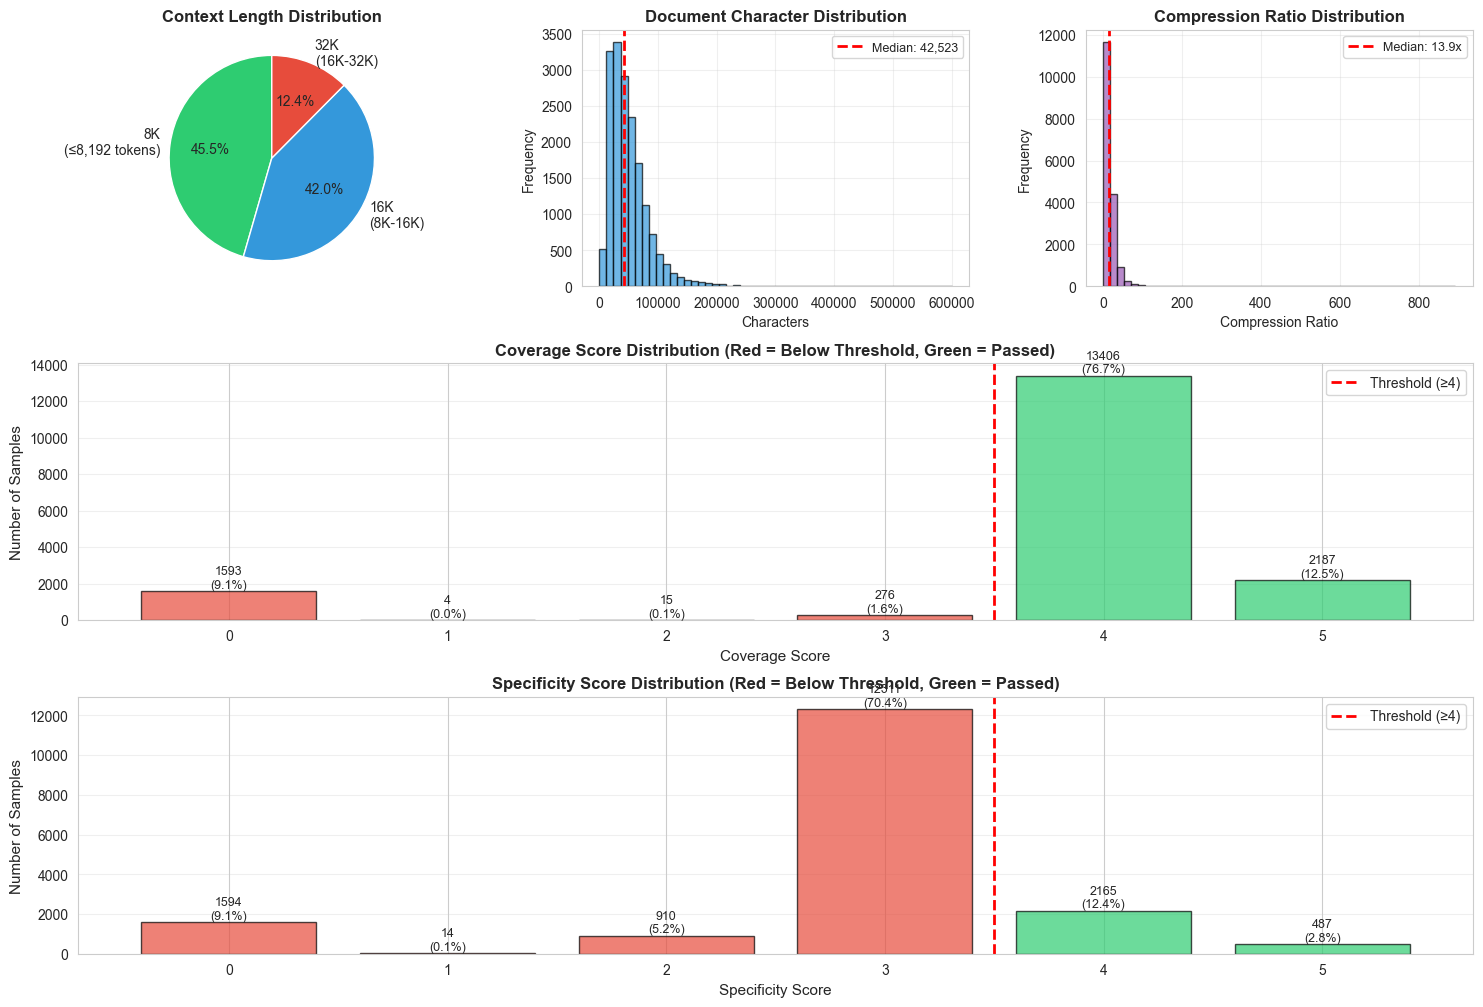


✓ Saved visualization: dataset_distribution.png


In [7]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Context length distribution (pie chart)
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#2ecc71', '#3498db', '#e74c3c']
pie_data = [category_counts.get('8K', 0), category_counts.get('16K', 0), category_counts.get('32K', 0)]
ax1.pie(
    pie_data,
    labels=['8K\n(≤8,192 tokens)', '16K\n(8K-16K)', '32K\n(16K-32K)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10}
)
ax1.set_title('Context Length Distribution', fontsize=12, fontweight='bold')

# 2. Document character distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(doc_chars, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
ax2.axvline(np.median(doc_chars), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_chars):,.0f}')
ax2.set_xlabel('Characters', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Document Character Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Compression ratio
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(compression_ratios, bins=50, alpha=0.7, color='#9b59b6', edgecolor='black')
ax3.axvline(np.median(compression_ratios), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(compression_ratios):.1f}x')
ax3.set_xlabel('Compression Ratio', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Compression Ratio Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Coverage score distribution
ax4 = fig.add_subplot(gs[1, :])
cov_scores = sorted(coverage_counts.keys())
cov_values = [coverage_counts[s] for s in cov_scores]
bars = ax4.bar(cov_scores, cov_values, color=['#e74c3c' if s < 4 else '#2ecc71' for s in cov_scores], alpha=0.7, edgecolor='black')
ax4.axvline(3.5, color='red', linestyle='--', linewidth=2, label='Threshold (≥4)')
ax4.set_xlabel('Coverage Score', fontsize=11)
ax4.set_ylabel('Number of Samples', fontsize=11)
ax4.set_title('Coverage Score Distribution (Red = Below Threshold, Green = Passed)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
for i, (score, val) in enumerate(zip(cov_scores, cov_values)):
    ax4.text(score, val, f'{val}\n({val/len(coverage_scores)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# 5. Specificity score distribution
ax5 = fig.add_subplot(gs[2, :])
spec_scores = sorted(specificity_counts.keys())
spec_values = [specificity_counts[s] for s in spec_scores]
bars = ax5.bar(spec_scores, spec_values, color=['#e74c3c' if s < 4 else '#2ecc71' for s in spec_scores], alpha=0.7, edgecolor='black')
ax5.axvline(3.5, color='red', linestyle='--', linewidth=2, label='Threshold (≥4)')
ax5.set_xlabel('Specificity Score', fontsize=11)
ax5.set_ylabel('Number of Samples', fontsize=11)
ax5.set_title('Specificity Score Distribution (Red = Below Threshold, Green = Passed)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')
for i, (score, val) in enumerate(zip(spec_scores, spec_values)):
    ax5.text(score, val, f'{val}\n({val/len(specificity_scores)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.savefig('dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: dataset_distribution.png")

## 7. Low Score Examples (Quality Issues)

Find samples with low but non-zero scores to understand quality problems.

In [8]:
# Find low-score samples (1-2 range, non-zero)
low_coverage = [d for d in all_data if 1 <= d['coverage'] <= 2]
low_specificity = [d for d in all_data if 1 <= d['specificity'] <= 2]

print("\n" + "="*80)
print("LOW SCORE EXAMPLES (Scores 1-2, Non-Zero)")
print("="*80)
print(f"\nSamples with low coverage (1-2): {len(low_coverage):,}")
print(f"Samples with low specificity (1-2): {len(low_specificity):,}")

print("\n" + "-"*80)
print("EXAMPLE 1: Low Coverage (Missing Key Points)")
print("-"*80)

if low_coverage:
    example = low_coverage[0]
    sample_id = example['sample_id']
    sample = train_data[sample_id]
    
    print(f"\nSample ID: {sample_id}")
    print(f"Coverage Score: {example['coverage']} / 5 ❌")
    print(f"Specificity Score: {example['specificity']} / 5")
    print(f"\n🔴 Issue: Missing major key points from document")
    print(f"   Summary does not comprehensively cover document content")
    
    print(f"\nDocument: {len(sample['report']):,} chars (~{len(sample['report'])//4:,} tokens)")
    print(f"Summary: {len(sample['summary']):,} chars (~{len(sample['summary'])//4:,} tokens)")
    print(f"Compression: {len(sample['report'])/len(sample['summary']):.1f}x")
    
    print(f"\nDocument Preview:")
    print("-" * 60)
    print(sample['report'][:500] + "...")
    
    print(f"\nSummary (Full):")
    print("-" * 60)
    print(sample['summary'])
else:
    print("\nNo low coverage examples found.")

print("\n" + "-"*80)
print("EXAMPLE 2: Low Specificity (Missing Details)")
print("-"*80)

if low_specificity:
    example = low_specificity[0]
    sample_id = example['sample_id']
    sample = train_data[sample_id]
    
    print(f"\nSample ID: {sample_id}")
    print(f"Coverage Score: {example['coverage']} / 5")
    print(f"Specificity Score: {example['specificity']} / 5 ❌")
    print(f"\n🔴 Issue: Missing specific details (numbers, dates, names)")
    print(f"   Summary is too generic without concrete facts")
    
    print(f"\nDocument: {len(sample['report']):,} chars")
    print(f"Summary: {len(sample['summary']):,} chars")
    
    # Analyze specificity
    numbers = re.findall(r'\b\d+(?:,\d{3})*(?:\.\d+)?%?\b|\$\d+', sample['summary'])
    dates = re.findall(r'\b\d{4}\b|(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},?\s+\d{4}', sample['summary'])
    names = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)+\b', sample['summary'])
    
    print(f"\nSpecificity Analysis:")
    print(f"  Numbers: {len(numbers)} occurrences {numbers[:5] if numbers else '(none)'}")
    print(f"  Dates/Years: {len(dates)} occurrences {dates[:3] if dates else '(none)'}")
    print(f"  Proper Names: {len(names)} occurrences {names[:3] if names else '(none)'}")
    print(f"  → Very generic summary, lacks factual details")
    
    print(f"\nSummary (Full):")
    print("-" * 60)
    print(sample['summary'])
else:
    print("\nNo low specificity examples found.")


LOW SCORE EXAMPLES (Scores 1-2, Non-Zero)

Samples with low coverage (1-2): 19
Samples with low specificity (1-2): 924

--------------------------------------------------------------------------------
EXAMPLE 1: Low Coverage (Missing Key Points)
--------------------------------------------------------------------------------

Sample ID: 11852
Coverage Score: 2 / 5 ❌
Specificity Score: 1 / 5

🔴 Issue: Missing major key points from document
   Summary does not comprehensively cover document content

Document: 14,604 chars (~3,651 tokens)
Summary: 1,219 chars (~304 tokens)
Compression: 12.0x

Document Preview:
------------------------------------------------------------
The Foreign Intelligence Surveillance Act of 1978 (FISA), P.L. 95-511 , 50 U.S.C. § 1801 et seq., as amended, provides a statutory framework for the U.S. government to engage in electronic surveillance and physical searches to obtain foreign intelligence information. It also provides a statutory structure for the installa

## 8. Borderline Examples (Score = 3, Just Below Threshold)

Samples that almost passed - understand what's missing to reach threshold.

In [9]:
# Find borderline samples (score = 3)
borderline_coverage = [d for d in all_data if d['coverage'] == 3]
borderline_specificity = [d for d in all_data if d['specificity'] == 3]

print("\n" + "="*80)
print("BORDERLINE EXAMPLES (Score = 3, Threshold = 4)")
print("="*80)
print(f"\nSamples with coverage = 3: {len(borderline_coverage):,}")
print(f"Samples with specificity = 3: {len(borderline_specificity):,}")

print("\n" + "-"*80)
print("EXAMPLE 3: Borderline Coverage (Score = 3)")
print("-"*80)

if borderline_coverage:
    example = borderline_coverage[0]
    sample_id = example['sample_id']
    sample = train_data[sample_id]
    
    print(f"\nSample ID: {sample_id}")
    print(f"Coverage Score: {example['coverage']} / 5 ⚠️ (threshold: ≥4)")
    print(f"Specificity Score: {example['specificity']} / 5")
    print(f"\n🟡 Why it didn't pass: Coverage slightly below threshold")
    print(f"   Missing 1-2 key points or sections from document")
    print(f"   Almost comprehensive but not quite complete")
    
    print(f"\nDocument: {len(sample['report']):,} chars")
    print(f"Summary: {len(sample['summary']):,} chars")
    
    print(f"\nSummary:")
    print("-" * 60)
    print(sample['summary'][:800] + "..." if len(sample['summary']) > 800 else sample['summary'])
else:
    print("\nNo borderline coverage examples found.")

print("\n" + "-"*80)
print("EXAMPLE 4: Borderline Specificity (Score = 3)")
print("-"*80)

if borderline_specificity:
    example = borderline_specificity[0]
    sample_id = example['sample_id']
    sample = train_data[sample_id]
    
    print(f"\nSample ID: {sample_id}")
    print(f"Coverage Score: {example['coverage']} / 5")
    print(f"Specificity Score: {example['specificity']} / 5 ⚠️ (threshold: ≥4)")
    print(f"\n🟡 Why it didn't pass: Not enough specific details")
    print(f"   Has some numbers/dates/names but needs more for score ≥4")
    print(f"   Moderately specific but not rich enough in concrete facts")
    
    print(f"\nDocument: {len(sample['report']):,} chars")
    print(f"Summary: {len(sample['summary']):,} chars")
    
    # Analyze specificity
    numbers = re.findall(r'\b\d+(?:,\d{3})*(?:\.\d+)?%?\b|\$\d+', sample['summary'])
    dates = re.findall(r'\b\d{4}\b', sample['summary'])
    names = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)+\b', sample['summary'])
    
    print(f"\nSpecificity Analysis:")
    print(f"  Numbers: {len(numbers)} (needs more)")
    print(f"  Years: {len(dates)} (needs more)")
    print(f"  Names: {len(names)} (needs more)")
    print(f"  → Moderate specificity, close but not enough")
    
    print(f"\nSummary:")
    print("-" * 60)
    print(sample['summary'][:800] + "..." if len(sample['summary']) > 800 else sample['summary'])
else:
    print("\nNo borderline specificity examples found.")


BORDERLINE EXAMPLES (Score = 3, Threshold = 4)

Samples with coverage = 3: 276
Samples with specificity = 3: 12,311

--------------------------------------------------------------------------------
EXAMPLE 3: Borderline Coverage (Score = 3)
--------------------------------------------------------------------------------

Sample ID: 9616
Coverage Score: 3 / 5 ⚠️ (threshold: ≥4)
Specificity Score: 2 / 5

🟡 Why it didn't pass: Coverage slightly below threshold
   Missing 1-2 key points or sections from document
   Almost comprehensive but not quite complete

Document: 42,343 chars
Summary: 1,013 chars

Summary:
------------------------------------------------------------
GAO discussed the Internal Revenue Service's (IRS) efforts to modernize the tax processing system. GAO noted that: (1) it has recently made numerous recommendations to IRS relating to its Tax Systems Modernization (TSM) effort; (2) IRS is making progress in maximizing electronic tax filing and controlling its systems and

## 9. Summary Statistics

In [10]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n📊 Dataset Overview:")
print(f"  Total GovReport samples: {len(train_data):,}")
print(f"  Total scored: {len(all_scores):,}")
print(f"  Successfully scored: {len(all_data):,} ({len(all_data)/len(all_scores)*100:.1f}%)")
print(f"  Failed scoring: {len(failed_scores):,} ({len(failed_scores)/len(all_scores)*100:.1f}%)")

print(f"\n📏 Context Distribution (All Scored):")
print(f"  8K:  {category_counts.get('8K', 0):5d} ({category_counts.get('8K', 0)/len(docs)*100:.1f}%)")
print(f"  16K: {category_counts.get('16K', 0):5d} ({category_counts.get('16K', 0)/len(docs)*100:.1f}%)")
print(f"  32K: {category_counts.get('32K', 0):5d} ({category_counts.get('32K', 0)/len(docs)*100:.1f}%)")

print(f"\n📝 Length Statistics (All Scored):")
print(f"  Avg document: {np.mean(doc_chars):,.0f} chars (~{np.mean(doc_tokens):,.0f} tokens)")
print(f"  Avg summary: {np.mean(summary_chars):,.0f} chars (~{np.mean(summary_tokens):,.0f} tokens)")
print(f"  Avg compression: {np.mean(compression_ratios):.1f}x")

print(f"\n⭐ Quality Distribution:")
print(f"  Coverage:")
for score in sorted(coverage_counts.keys()):
    count = coverage_counts[score]
    status = "✅" if score >= 4 else "❌"
    print(f"    Score {score}: {count:5d} ({count/len(coverage_scores)*100:5.1f}%) {status}")
    
print(f"\n  Specificity:")
for score in sorted(specificity_counts.keys()):
    count = specificity_counts[score]
    status = "✅" if score >= 4 else "❌"
    print(f"    Score {score}: {count:5d} ({count/len(specificity_scores)*100:5.1f}%) {status}")

print(f"\n🎯 Filter Results (Coverage ≥4 AND Specificity ≥4):")
print(f"  Passed: {len(high_quality):,} samples ({len(high_quality)/len(all_data)*100:.1f}%)")
print(f"  Filtered out: {len(all_data) - len(high_quality):,} samples ({(len(all_data) - len(high_quality))/len(all_data)*100:.1f}%)")

print(f"\n💡 Key Insights:")
print(f"  • Only {len(high_quality)/len(all_data)*100:.1f}% of scored samples pass strict quality filter")
print(f"  • Training on {len(high_quality):,} high-quality samples")
print(f"  • Use 32K max_seq_length to cover all data")
print(f"  • Focus adapter training on improving coverage + specificity")
print(f"  • Small dataset → high dropout (0.15) + weight decay (0.15)")

print("\n" + "="*80)


FINAL SUMMARY

📊 Dataset Overview:
  Total GovReport samples: 17,517
  Total scored: 18,490
  Successfully scored: 17,481 (94.5%)
  Failed scoring: 38 (0.2%)

📏 Context Distribution (All Scored):
  8K:   7823 (44.8%)
  16K:  7220 (41.3%)
  32K:  2137 (12.2%)

📝 Length Statistics (All Scored):
  Avg document: 50,880 chars (~9,921 tokens)
  Avg summary: 3,202 chars (~622 tokens)
  Avg compression: 17.9x

⭐ Quality Distribution:
  Coverage:
    Score 0:  1593 (  9.1%) ❌
    Score 1:     4 (  0.0%) ❌
    Score 2:    15 (  0.1%) ❌
    Score 3:   276 (  1.6%) ❌
    Score 4: 13406 ( 76.7%) ✅
    Score 5:  2187 ( 12.5%) ✅

  Specificity:
    Score 0:  1594 (  9.1%) ❌
    Score 1:    14 (  0.1%) ❌
    Score 2:   910 (  5.2%) ❌
    Score 3: 12311 ( 70.4%) ❌
    Score 4:  2165 ( 12.4%) ✅
    Score 5:   487 (  2.8%) ✅

🎯 Filter Results (Coverage ≥4 AND Specificity ≥4):
  Passed: 2,636 samples (15.1%)
  Filtered out: 14,845 samples (84.9%)

💡 Key Insights:
  • Only 15.1% of scored samples pass str

## 10. Word Count Distribution Analysis

NameError: name 'doc_words' is not defined

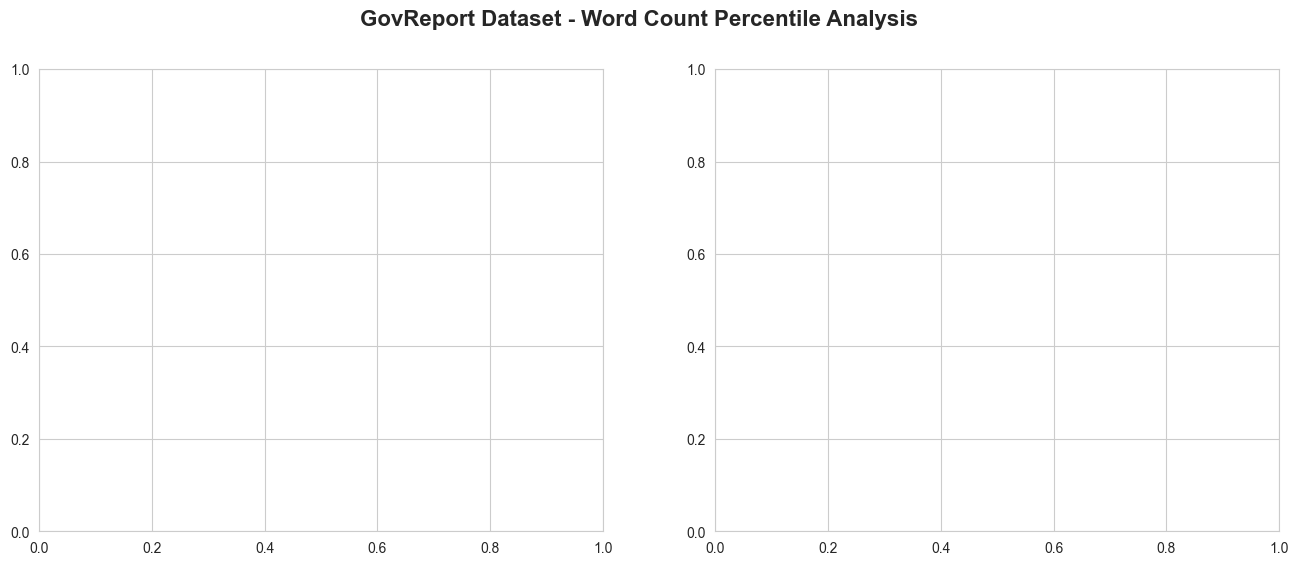

In [11]:
# Create percentile analysis plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GovReport Dataset - Word Count Percentile Analysis', fontsize=16, fontweight='bold')

# Document percentiles
ax = axes[0]
percentiles = [10, 25, 50, 75, 90, 95, 99]
doc_percentiles = [np.percentile(doc_words, p) for p in percentiles]
bars = ax.bar([str(p) for p in percentiles], doc_percentiles, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.set_title('Document Word Count by Percentile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(doc_percentiles):
    ax.text(i, v + 200, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Summary percentiles
ax = axes[1]
sum_percentiles = [np.percentile(summary_words, p) for p in percentiles]
bars = ax.bar([str(p) for p in percentiles], sum_percentiles, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.set_title('Summary Word Count by Percentile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(sum_percentiles):
    ax.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('word_percentile_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved plot: word_percentile_analysis.png")

In [ ]:
# Create word count distribution plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GovReport Dataset - Word Count Distribution', fontsize=16, fontweight='bold')

# 1. Document word count distribution (full range)
ax = axes[0, 0]
ax.hist(doc_words, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(doc_words), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(doc_words):.0f}')
ax.axvline(np.median(doc_words), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_words):.0f}')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Document Word Count Distribution (Full Range)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Document word count distribution (zoomed to 95th percentile)
ax = axes[0, 1]
p95 = np.percentile(doc_words, 95)
filtered_doc = [w for w in doc_words if w <= p95]
ax.hist(filtered_doc, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(doc_words), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(doc_words):.0f}')
ax.axvline(np.median(doc_words), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_words):.0f}')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Document Word Count (Up to P95: {p95:.0f} words)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Summary word count distribution
ax = axes[1, 0]
ax.hist(summary_words, bins=100, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(summary_words), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(summary_words):.0f}')
ax.axvline(np.median(summary_words), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(summary_words):.0f}')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Summary Word Count Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Document vs Summary scatter plot (sampled)
ax = axes[1, 1]
sample_size = min(5000, len(doc_words))
indices = np.random.choice(len(doc_words), sample_size, replace=False)
doc_sample = [doc_words[i] for i in indices]
sum_sample = [summary_words[i] for i in indices]
ax.scatter(doc_sample, sum_sample, alpha=0.3, s=10, color='purple')
ax.set_xlabel('Document Words', fontsize=12)
ax.set_ylabel('Summary Words', fontsize=12)
ax.set_title(f'Document vs Summary Length (n={sample_size:,} samples)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add compression ratio line
compression_ratio = np.mean(summary_words) / np.mean(doc_words)
x_range = np.linspace(0, max(doc_words), 100)
ax.plot(x_range, x_range * compression_ratio, 'r--', linewidth=2,
        label=f'Avg Compression: {compression_ratio:.2%}')
ax.legend()

plt.tight_layout()
plt.savefig('word_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved plot: word_distribution.png")

In [ ]:
# Count words in documents and summaries
def count_words(text):
    return len(text.split())

print("Counting words in all samples...")
doc_words = [count_words(d) for d in docs]
summary_words = [count_words(s) for s in summaries]

print("\n" + "="*80)
print("WORD COUNT STATISTICS (All Scored Samples)")
print("="*80)

print("\nDocuments:")
print(f"  Mean:   {np.mean(doc_words):,.0f} words")
print(f"  Median: {np.median(doc_words):,.0f} words")
print(f"  Min:    {min(doc_words):,} words")
print(f"  Max:    {max(doc_words):,} words")
print(f"  Std:    {np.std(doc_words):,.0f} words")
print(f"  P25:    {np.percentile(doc_words, 25):,.0f} words")
print(f"  P75:    {np.percentile(doc_words, 75):,.0f} words")
print(f"  P90:    {np.percentile(doc_words, 90):,.0f} words")
print(f"  P95:    {np.percentile(doc_words, 95):,.0f} words")
print(f"  P99:    {np.percentile(doc_words, 99):,.0f} words")

print("\nSummaries:")
print(f"  Mean:   {np.mean(summary_words):,.0f} words")
print(f"  Median: {np.median(summary_words):,.0f} words")
print(f"  Min:    {min(summary_words):,} words")
print(f"  Max:    {max(summary_words):,} words")
print(f"  Std:    {np.std(summary_words):,.0f} words")
print(f"  P25:    {np.percentile(summary_words, 25):,.0f} words")
print(f"  P75:    {np.percentile(summary_words, 75):,.0f} words")
print(f"  P90:    {np.percentile(summary_words, 90):,.0f} words")
print(f"  P95:    {np.percentile(summary_words, 95):,.0f} words")
print(f"  P99:    {np.percentile(summary_words, 99):,.0f} words")

print("\nCompression Ratio (words):")
word_compression = [d/s if s > 0 else 0 for d, s in zip(doc_words, summary_words)]
print(f"  Mean:   {np.mean(word_compression):.1f}x")
print(f"  Median: {np.median(word_compression):.1f}x")